<a href="https://colab.research.google.com/github/JeanMusenga/SZUniversity/blob/main/Postive_Score_1_Better_Finall_CPArchISLinker_With_Threshold_on_Classification_Head.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q sentence-transformers rapidfuzz openpyxl

In [ ]:
import torch, random, re, numpy as np, pandas as pd
import torch.nn as nn
from sentence_transformers import SentenceTransformer
from rapidfuzz import fuzz
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt


# ------------------ Reproducibility ------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# ------------------ Load Dataset ------------------
PATH = "Dataset_GitHub_Solutions.xlsx"
df = pd.read_excel(PATH)
required = {'commit_id','so_id','p_text','s_text','label'}
assert required.issubset(df.columns)
df['label'] = df['label'].astype(int)

commit_ids = df.commit_id.unique()
N_SPLITS = 10 # 10-fold cross validation
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# I. Preprocessing Layer

In [ ]:
# ------------------ Preprocessing ------------------
def clean_text(s):
    if pd.isna(s): return ""
    s = str(s).lower()
    s = re.sub(r"`{3}.*?`{3}", " ", s, flags=re.S)
    s = re.sub(r"<[^>]+>", " ", s)
    s = re.sub(r"&[a-zA-Z]+;", " ", s)
    s = re.sub(r"[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF"
               r"\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\u2702-\u27B0\u24C2-\U0001F251]+", '', s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

# II. Feature Extraction

In [ ]:
# ------------------ Embeddings ------------------
sbert = SentenceTransformer("all-MiniLM-L6-v2", device=device)
_EMB = {}
def embed(text):
    text = text.strip().lower()
    if text not in _EMB:
        _EMB[text] = sbert.encode(text, normalize_embeddings=True, convert_to_numpy=True).astype(np.float32)
    return _EMB[text]

# ------------------ Feature Functions ------------------
commit_kw = {cid: re.findall(r"\b\w+\b", txt) for cid, txt in zip(df.commit_id, df.p_text)}
ACTION_VERBS = {"optimize", "refactor", "migrate", "replace", "remove", "add", "improve", "reduce", "fix"}

PROBLEM_TERMS = {
    "performance": ["latency","slow","bottleneck","throughput","performance"],
    "scalability": ["scale","scaling","load","traffic","high traffic"],
    "security": ["authentication","authorization","vulnerability","security","encryption"],
    "maintainability": ["refactor","technical debt","maintainability","clean code"],
    "reliability": ["crash","failure","availability","reliability","fault"],
    "deployment": ["deployment","docker","kubernetes","ci/cd"],
    "communication": ["communication","rpc","rest","http","message"],
    "anti_pattern": ["god class","spaghetti","anti-pattern"],
}

SOLUTION_TERMS = {
    "architectural_pattern": ["microservice","mvc","layered","event-driven"],
    "architectural_tactic": ["caching","load balancing","replication"],
    "framework": ["spring","django","react","flask"],
    "api": ["api","rest","grpc"],
    "protocol": ["http","https","tcp"],
    "refactoring": ["refactor","restructure","redesign"],
}

def lexical_score(cid, s_text):
    kws = commit_kw.get(cid, [])
    return np.mean([fuzz.partial_ratio(k, s_text)/100 for k in kws]) if kws else 0.0

def semantic_score(vp, vs):
    return cosine_similarity(vp.reshape(1,-1), vs.reshape(1,-1))[0,0]

def contains_any(text, terms): return any(t in text for t in terms)
def extract_actions(text): return {v for v in ACTION_VERBS if v in text}
def association_score(p_text,s_text):
    p,s = p_text.lower(), s_text.lower()
    r1 = any(contains_any(p,v) and contains_any(s,v) for v in PROBLEM_TERMS.values())
    r2 = any(contains_any(p,v) and contains_any(s,v) for v in SOLUTION_TERMS.values())
    r3 = bool(extract_actions(p) & extract_actions(s))
    return np.mean([r1,r2,r3])

def compute_mci(L,S,A,α=0.3,β=0.4,γ=0.3): return α*L+β*S+γ*A

def build_features(row):
    vp,vs = embed(row.p_text), embed(row.s_text)
    L,S,A = lexical_score(row.commit_id,row.s_text), semantic_score(vp,vs), association_score(row.p_text,row.s_text)
    return np.array([L,S,A,compute_mci(L,S,A)],dtype=np.float32)

def build_matrix(df):
    X = np.vstack(df.apply(build_features,axis=1))
    y = df.label.values.astype(np.float32)
    return X,y

def build_fold_data(df, train_cids, test_cids):
    df_tr, df_te = df[df.commit_id.isin(train_cids)].copy(), df[df.commit_id.isin(test_cids)].copy()
    Xtr, ytr = build_matrix(df_tr)
    Xte, yte = build_matrix(df_te)
    sc = StandardScaler().fit(Xtr)
    Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    return df_tr, df_te, torch.tensor(Xtr,device=device), torch.tensor(Xte,device=device), torch.tensor(ytr,device=device), torch.tensor(yte,device=device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# III Relevancy Identification Layer

## Stage-1 DML

In [ ]:
# ======================== Stage-1 DML ========================
class DML_Stage1(nn.Module):
    def __init__(self, d):
        super().__init__()

        # --- 3-layer DML embedding (as in original paper) ---
        self.embed = nn.Sequential(
            nn.Linear(d, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64)
        )

        # ---- our added classification head ---
        self.cls = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        h = self.embed(x) # embedding metric learning
        h = h / (h.norm(dim=1, keepdim=True) + 1e-9)  # metric normalization
        logits = self.cls(h)
        return logits.squeeze(), h

# ------- Hard negative mining-----
def mine_hard_negatives(df_split,H):
    idx_map = {idx:i for i,idx in enumerate(df_split.index)}
    pairs=[]
    for cid,g in df_split.groupby("commit_id"):
        pos=g[g.label==1].index
        neg=g[g.label==0].index
        for p in pos:
            sims=[np.dot(H[idx_map[p]],H[idx_map[n]]) for n in neg]
            if sims:
                hard_n=neg[np.argmax(sims)]
                pairs.append((p,hard_n))
    return pairs

def train_stage1(df_tr,Xtr_t,ytr_t,epochs=5):
    net=DML_Stage1(Xtr_t.shape[1]).to(device)
    opt=torch.optim.Adam(net.parameters(),lr=1e-3)
    loss_fn=nn.BCEWithLogitsLoss()
    for epoch in range(epochs):
        net.train()
        with torch.no_grad(): _,H = net(Xtr_t)
        H=H.cpu().numpy()
        pairs=mine_hard_negatives(df_tr,H)
        random.shuffle(pairs)
        total_loss=0.0
        for p,n in pairs:
            Xp,Xn=Xtr_t[df_tr.index.get_loc(p)], Xtr_t[df_tr.index.get_loc(n)]
            xb = torch.stack([Xp,Xn])
            yb = torch.tensor([1.0,0.0],device=device)
            opt.zero_grad(); loss=loss_fn(net(xb)[0],yb); loss.backward(); opt.step()
            total_loss += loss.item()
        print(f"[Stage1] Epoch {epoch+1}/{epochs} | Avg Loss: {total_loss/max(len(pairs),1):.4f}")
    return net

def evaluate_stage1(net,Xte_t,yte_t):
    net.eval()
    with torch.no_grad():
        logits,_=net(Xte_t)
        probs=torch.sigmoid(logits).detach().cpu().numpy()
        preds=(probs>=0.5).astype(int)
    y_true=yte_t.cpu().numpy()
    p,r,f,_=precision_recall_fscore_support(y_true,preds,average="binary")
    auc=roc_auc_score(y_true,probs)
    return {"P":p,"R":r,"F1":f,"AUC":auc}, probs


## Traning and Evaluation Stage-1

In [ ]:
# ========== Stage-1 K-Fold Training, Evaluation, and Precomputation ==========
stage1_metrics = []
stage1_probs = {}

all_y_true = []
all_y_pred = []
threshold = 0.5

print("\n===== Stage-1 K-Fold Training =====")
for fold, (train_idx, test_idx) in enumerate(kf.split(commit_ids), 1):
    print(f"\n[Stage-1] Fold {fold}/{N_SPLITS}")

    train_cids, test_cids = commit_ids[train_idx], commit_ids[test_idx]
    df_tr, df_te, Xtr_t, Xte_t, ytr_t, yte_t = build_fold_data(
        df, train_cids, test_cids
    )

    # ---- Train ----
    net = train_stage1(df_tr, Xtr_t, ytr_t, epochs=5)

    # ---- Evaluate ----
    metrics, probs = evaluate_stage1(net, Xte_t, yte_t)
    stage1_metrics.append(metrics)

    # ---- Ensure NumPy on CPU ----
    probs_np = (
        probs.detach().cpu().numpy()
        if isinstance(probs, torch.Tensor)
        else np.array(probs)
    )
    yte_np = (
        yte_t.detach().cpu().numpy()
        if isinstance(yte_t, torch.Tensor)
        else np.array(yte_t)
    )

    # ---- Aggregate predictions for later analysis ----
    y_pred = (probs_np >= threshold).astype(int)
    all_y_true.extend(yte_np)
    all_y_pred.extend(y_pred)

    # ---- Store Stage-1 probabilities for Stage-2 ----
    for i, cid in enumerate(df_te.commit_id):
        stage1_probs[cid] = probs_np[i]

# ================= Stage-1 CV Metrics =================
print("\n===== Stage-1 CV Results =====")
for k in ["P", "R", "F1", "AUC"]:
    vals = [m[k] for m in stage1_metrics]
    print(f"{k}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# ================= Precompute for Stage-2 =================
print("\nPrecomputing embeddings and Stage-1 probabilities for Stage-2...")
df["H"] = df["p_text"].apply(embed)
df["stage1_prob"] = df["commit_id"].map(stage1_probs)



===== Stage-1 K-Fold Training =====

[Stage-1] Fold 1/10
[Stage1] Epoch 1/5 | Avg Loss: 0.1872
[Stage1] Epoch 2/5 | Avg Loss: 0.1263
[Stage1] Epoch 3/5 | Avg Loss: 0.1176
[Stage1] Epoch 4/5 | Avg Loss: 0.1148
[Stage1] Epoch 5/5 | Avg Loss: 0.1079

[Stage-1] Fold 2/10
[Stage1] Epoch 1/5 | Avg Loss: 0.1906
[Stage1] Epoch 2/5 | Avg Loss: 0.1206
[Stage1] Epoch 3/5 | Avg Loss: 0.1151
[Stage1] Epoch 4/5 | Avg Loss: 0.1102
[Stage1] Epoch 5/5 | Avg Loss: 0.1082

[Stage-1] Fold 3/10
[Stage1] Epoch 1/5 | Avg Loss: 0.1866
[Stage1] Epoch 2/5 | Avg Loss: 0.1154
[Stage1] Epoch 3/5 | Avg Loss: 0.1225
[Stage1] Epoch 4/5 | Avg Loss: 0.1113
[Stage1] Epoch 5/5 | Avg Loss: 0.1101

[Stage-1] Fold 4/10
[Stage1] Epoch 1/5 | Avg Loss: 0.1824
[Stage1] Epoch 2/5 | Avg Loss: 0.1151
[Stage1] Epoch 3/5 | Avg Loss: 0.1102
[Stage1] Epoch 4/5 | Avg Loss: 0.1029
[Stage1] Epoch 5/5 | Avg Loss: 0.1030

[Stage-1] Fold 5/10
[Stage1] Epoch 1/5 | Avg Loss: 0.1831
[Stage1] Epoch 2/5 | Avg Loss: 0.1196
[Stage1] Epoch 3/5 | A

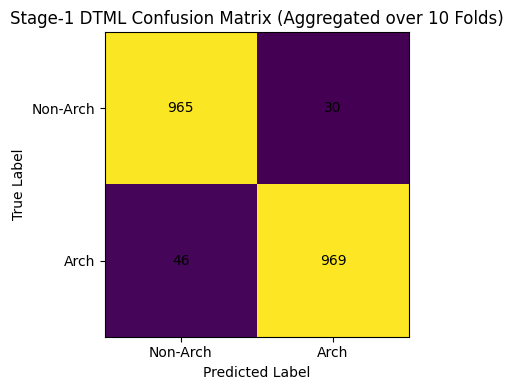

In [ ]:

# ========== Aggregated Confusion Matrix Plot ==========
cm = confusion_matrix(all_y_true, all_y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_title("Stage-1 DML Confusion Matrix (Aggregated over 10 Folds)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

# Tick labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Non-Arch", "Arch"])
ax.set_yticklabels(["Non-Arch", "Arch"])

# Annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center")

plt.tight_layout()
plt.show()


# IV. Linking and Recommendation Layer

## Stage-2 RankNet-based Model

In [ ]:
# ==========================================================
# Stage-2 RankNet Training & Evaluation
# ==========================================================

class RankNet(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Softplus()  # Applying Softplus to make the output always positive
        )
    def forward(self, x):
        return self.net(x).squeeze()




In [ ]:
# ==========================================================
# Improved Stage-2 Training with Stage-1 Filtering + Hard Negatives
# ==========================================================

MARGIN = 1.5  # margin for pairwise ranking
STAGE1_THRESH = 0.3  # only consider candidates with Stage-1 prob >= 0.3
TOP_M = 15         # max candidates per commit

# --- Helper: Normalize features per fold ---
def normalize_features(X):
    scaler = StandardScaler()
    return scaler.fit_transform(X), scaler

# --- Build Stage-2 candidates using Stage-1 probability filter ---
def build_stage2_candidates_filtered(df_split, X_raw, probs, H_split, top_m=TOP_M, threshold=STAGE1_THRESH):
    all_feats = np.hstack([X_raw, probs.reshape(-1,1)])  # include Stage-1 prob as feature
    candidates = {}
    for cid, g in df_split.groupby("commit_id"):
        own_idx = [df_split.index.get_loc(i) for i in g.index]
        anchor_idx = own_idx[0]

        # Compute cosine similarity to all candidates
        sims = cosine_similarity(H_split[anchor_idx].reshape(1,-1), H_split).flatten()

        tmp = df_split.copy()
        tmp['sim'] = sims
        tmp['stage1_prob'] = probs
        tmp['pos'] = range(len(tmp))

        # Stage-1 filtering + top-m similarity
        tmp = tmp[(tmp.stage1_prob >= threshold) & (tmp.commit_id != cid)]
        tmp = tmp.sort_values('sim', ascending=False).head(top_m)

        candidates[cid] = list(set(own_idx + tmp['pos'].tolist()))
    return candidates, all_feats

# --- Build Stage-2 pairwise training set ---
def build_stage2_pairs_filtered(df_train, candidates, all_feats):
    pairs = []
    for cid, idx_list in candidates.items():
        g = df_train[df_train.commit_id==cid]
        pos_idx = [df_train.index.get_loc(i) for i in g[g.label==1].index]
        neg_idx = [i for i in idx_list if i not in pos_idx]
        # Only select hard negatives: top 50% by cosine similarity to positive
        for fp in pos_idx:
            if not neg_idx:
                continue
            # compute similarity of negatives to positive
            sims = [np.dot(all_feats[fp], all_feats[n]) for n in neg_idx]
            n_hard = max(1, len(neg_idx)//2)
            hard_neg_idx = [neg_idx[i] for i in np.argsort(sims)[-n_hard:]]
            for fn in hard_neg_idx:
                # augment features: add difference vector
                fp_feat = np.concatenate([all_feats[fp], all_feats[fp]-all_feats[fn]])
                fn_feat = np.concatenate([all_feats[fn], all_feats[fp]-all_feats[fn]])
                pairs.append((fp_feat, fn_feat))
    return pairs

# --- Pairwise margin ranking loss ---
def pairwise_rank_loss(sp, sn, margin=MARGIN):
    return torch.mean(torch.clamp(margin - (sp - sn), min=0))

# --- Stage-2 training ---
def train_stage2_filtered(df_train, X_raw, probs, H_split, epochs=5, top_m=TOP_M):
    candidates, all_feats = build_stage2_candidates_filtered(df_train, X_raw, probs, H_split, top_m)
    train_pairs = build_stage2_pairs_filtered(df_train, candidates, all_feats)
    if len(train_pairs)==0:
        return None

    # Normalize features
    X_all = np.vstack([p[0] for p in train_pairs] + [p[1] for p in train_pairs])
    X_all, scaler = normalize_features(X_all)
    for i, (fp, fn) in enumerate(train_pairs):
        train_pairs[i] = (X_all[i], X_all[i+len(train_pairs)])

    ranker = RankNet(train_pairs[0][0].shape[0]).to(device)
    opt = torch.optim.Adam(ranker.parameters(), lr=1e-3)

    for epoch in range(epochs):
        random.shuffle(train_pairs)
        total_loss = 0.0
        for fp, fn in train_pairs:
            fp_t = torch.tensor(fp, device=device)
            fn_t = torch.tensor(fn, device=device)
            loss = pairwise_rank_loss(ranker(fp_t), ranker(fn_t))
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
        print(f"[Stage2] Epoch {epoch+1}/{epochs} | Avg Loss: {total_loss/len(train_pairs):.4f}")
    return ranker, scaler

# --- Stage-2 evaluation ---
def evaluate_stage2_filtered(df_split, X_raw, probs, H_split, ranker, scaler, top_k=[3,5,10,15]):
    candidates, all_feats = build_stage2_candidates_filtered(df_split, X_raw, probs, H_split)
    all_feats_aug = np.hstack([all_feats, np.zeros_like(all_feats)])  # placeholder for diff vector
    all_feats_norm = scaler.transform(all_feats_aug)
    all_feats_t = torch.tensor(all_feats_norm, device=device)

    hr = {f"HR@{k}":0 for k in top_k}
    mrr = []

    with torch.no_grad():
        scores = ranker(all_feats_t).cpu().numpy()

    for cid, idx_list in candidates.items():
        g = df_split[df_split.commit_id==cid]
        pos_idx = [df_split.index.get_loc(i) for i in g[g.label==1].index]
        candidate_scores = scores[idx_list]
        ranked_idx = np.argsort(-candidate_scores)

        for k in top_k:
            topk_idx = [idx_list[i] for i in ranked_idx[:k]]
            if any(i in pos_idx for i in topk_idx):
                hr[f"HR@{k}"] += 1

        # MRR
        rank_positions = [np.where(ranked_idx==idx_list.index(idx))[0][0]+1 for idx in pos_idx if idx in idx_list]
        if rank_positions:
            mrr.append(1/min(rank_positions))

    n = len(df_split.commit_id.unique())
    hr = {k:v/n for k,v in hr.items()}
    mrr = np.mean(mrr) if mrr else 0.0
    return hr, mrr


## Stage-2 K-Fold Cross-Valiadation

In [ ]:
# ==========================================================
# Full Improved Stage-2 K-Fold CV with per-fold HR and MRR
# ==========================================================
epochs2 = 5
TOP_M = 15
STAGE1_THRESH = 0.3

stage2_metrics = []

print("\n===== Improved Stage-2 K-Fold CV =====")
for fold, (train_idx, test_idx) in enumerate(kf.split(commit_ids), 1):
    print(f"\n[Stage-2] Fold {fold}/{N_SPLITS}")

    train_cids = commit_ids[train_idx]
    test_cids = commit_ids[test_idx]

    df_tr, df_te = df[df.commit_id.isin(train_cids)].copy(), df[df.commit_id.isin(test_cids)].copy()
    Xtr, _ = build_matrix(df_tr)
    Xte, _ = build_matrix(df_te)
    Htr = np.vstack(df_tr['H'].to_numpy())
    Hte = np.vstack(df_te['H'].to_numpy())
    probs_tr = df_tr['stage1_prob'].to_numpy()
    probs_te = df_te['stage1_prob'].to_numpy()

    # Train Stage-2 ranker
    ranker, scaler = train_stage2_filtered(df_tr, Xtr, probs_tr, Htr, epochs=epochs2, top_m=TOP_M)

    # Evaluate
    hr, mrr = evaluate_stage2_filtered(df_te, Xte, probs_te, Hte, ranker, scaler)
    stage2_metrics.append({"HR": hr, "MRR": mrr})

    # Print per-fold HR@k
    print(f"HR: {{", end="")
    print(", ".join([f"HR@{k}: {v:.4f}" for k,v in hr.items()]), end="")
    print(f"}}, MRR: {mrr:.4f}")


===== Improved Stage-2 K-Fold CV =====

[Stage-2] Fold 1/10
[Stage2] Epoch 1/5 | Avg Loss: 0.0212
[Stage2] Epoch 2/5 | Avg Loss: 0.0031
[Stage2] Epoch 3/5 | Avg Loss: 0.0026
[Stage2] Epoch 4/5 | Avg Loss: 0.0014
[Stage2] Epoch 5/5 | Avg Loss: 0.0012
HR: {HR@HR@3: 1.0000, HR@HR@5: 1.0000, HR@HR@10: 1.0000, HR@HR@15: 1.0000}, MRR: 0.8788

[Stage-2] Fold 2/10
[Stage2] Epoch 1/5 | Avg Loss: 0.0182
[Stage2] Epoch 2/5 | Avg Loss: 0.0032
[Stage2] Epoch 3/5 | Avg Loss: 0.0024
[Stage2] Epoch 4/5 | Avg Loss: 0.0021
[Stage2] Epoch 5/5 | Avg Loss: 0.0010
HR: {HR@HR@3: 0.8081, HR@HR@5: 0.9394, HR@HR@10: 0.9495, HR@HR@15: 0.9899}, MRR: 0.5037

[Stage-2] Fold 3/10
[Stage2] Epoch 1/5 | Avg Loss: 0.0175
[Stage2] Epoch 2/5 | Avg Loss: 0.0029
[Stage2] Epoch 3/5 | Avg Loss: 0.0029
[Stage2] Epoch 4/5 | Avg Loss: 0.0021
[Stage2] Epoch 5/5 | Avg Loss: 0.0009
HR: {HR@HR@3: 0.4747, HR@HR@5: 0.5859, HR@HR@10: 0.9091, HR@HR@15: 0.9798}, MRR: 0.4249

[Stage-2] Fold 4/10
[Stage2] Epoch 1/5 | Avg Loss: 0.0193
[Sta

## Stage-2 valuation Results

In [ ]:
# Compute overall CV results
print("\n===== Stage-2 CV Results (Improved) =====")
for k in ["HR@3", "HR@5", "HR@10", "HR@15", "MRR"]:
    if k == "MRR":
        vals = [m["MRR"] for m in stage2_metrics]
    else:
        vals = [m["HR"][k] for m in stage2_metrics]
    print(f"{k}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")


===== Stage-2 CV Results (Improved) =====
HR@3: 0.6793 ± 0.2984
HR@5: 0.8066 ± 0.2274
HR@10: 0.9767 ± 0.0372
HR@15: 0.9970 ± 0.0065
MRR: 0.5514 ± 0.2376


## Saving the Results

In [ ]:
# ================== Stage-2 Inference / Global Top-15 Aggregation ==================

# --- Step 1: Build Stage-2 features (X_full) ---
def build_stage2_features(df):
    feats = []
    for _, row in df.iterrows():
        vp, vs = embed(row.p_text), embed(row.s_text)
        L = lexical_score(row.commit_id, row.s_text)
        S = semantic_score(vp, vs)
        A = association_score(row.p_text, row.s_text)
        MCI = compute_mci(L, S, A)
        feats.append([L, S, A, MCI, row.stage1_prob])
    return np.array(feats, dtype=np.float32)

X_full = build_stage2_features(df)

# --- Step 2: Load / use Stage-2 ranker and scaler ---
scaler_full = scaler   # from last fold or loaded
ranker_full = ranker   # from last fold or loaded
ranker_full.eval()

# --- Step 3: Augment features if necessary ---
n_feats_aug = scaler_full.n_features_in_ - X_full.shape[1]
if n_feats_aug < 0:
    raise ValueError(f"X_full has MORE features ({X_full.shape[1]}) than scaler expects ({scaler_full.n_features_in_})")

X_aug = np.hstack([X_full, np.zeros((X_full.shape[0], n_feats_aug))])

# --- Step 4: Scale and convert to tensor ---
X_scaled = scaler_full.transform(X_aug)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32, device=device)

# --- Step 5: Compute Stage-2 scores ---
with torch.no_grad():
    scores = ranker_full(X_tensor).cpu().numpy()

df['stage2_score'] = scores

# --- Step 6: Global Top-15 ranking ---
df_sorted = df.sort_values(by='stage2_score', ascending=False).reset_index(drop=True)
df_sorted['stage2_global_rank'] = np.arange(1, len(df_sorted)+1)


# ================== Stage-2 Inference / Top-15 Aggregation ==================

top_results = []

for cid, g in df.groupby('commit_id'):
    ranked_idx = np.argsort(-g['stage2_score'].to_numpy())[:15]  # Top-15 scores
    for rank, idx in enumerate(ranked_idx, 1):
        row = g.iloc[idx]
        top_results.append({
            "commit_id": row['commit_id'],
            "so_id": row['so_id'],
            "p_text": row['p_text'],
            "s_text": row['s_text'],
            "Relevant/Irrelevant": row['Relevant/Irrelevant'],  # use existing column
            "H": row['H'],
            "stage1_prob": row['stage1_prob'],
            "stage2_score": row['stage2_score'],
            "stage2_rank": rank
        })

df_stage2_top = pd.DataFrame(top_results)
df_stage2_top.sort_values(by=['commit_id', 'stage2_rank'], inplace=True)

# --- Save to Excel ---
excel_path = "./stage2_top15_results.xlsx"
df_stage2_top.to_excel(excel_path, index=False)
print(f"Top-15 Stage-2 results saved to Excel: {excel_path}")



Top-15 Stage-2 results saved to Excel: ./stage2_top15_results.xlsx


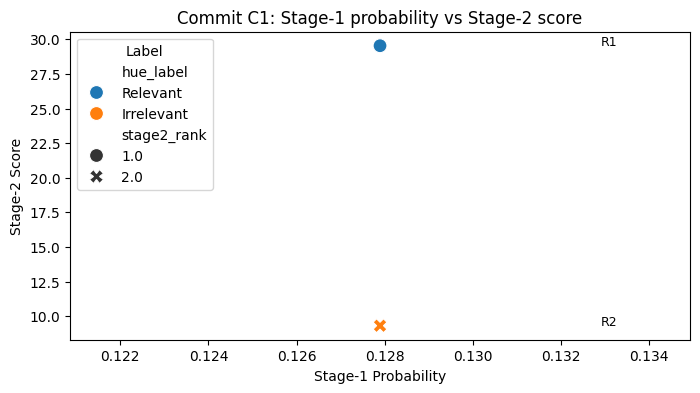

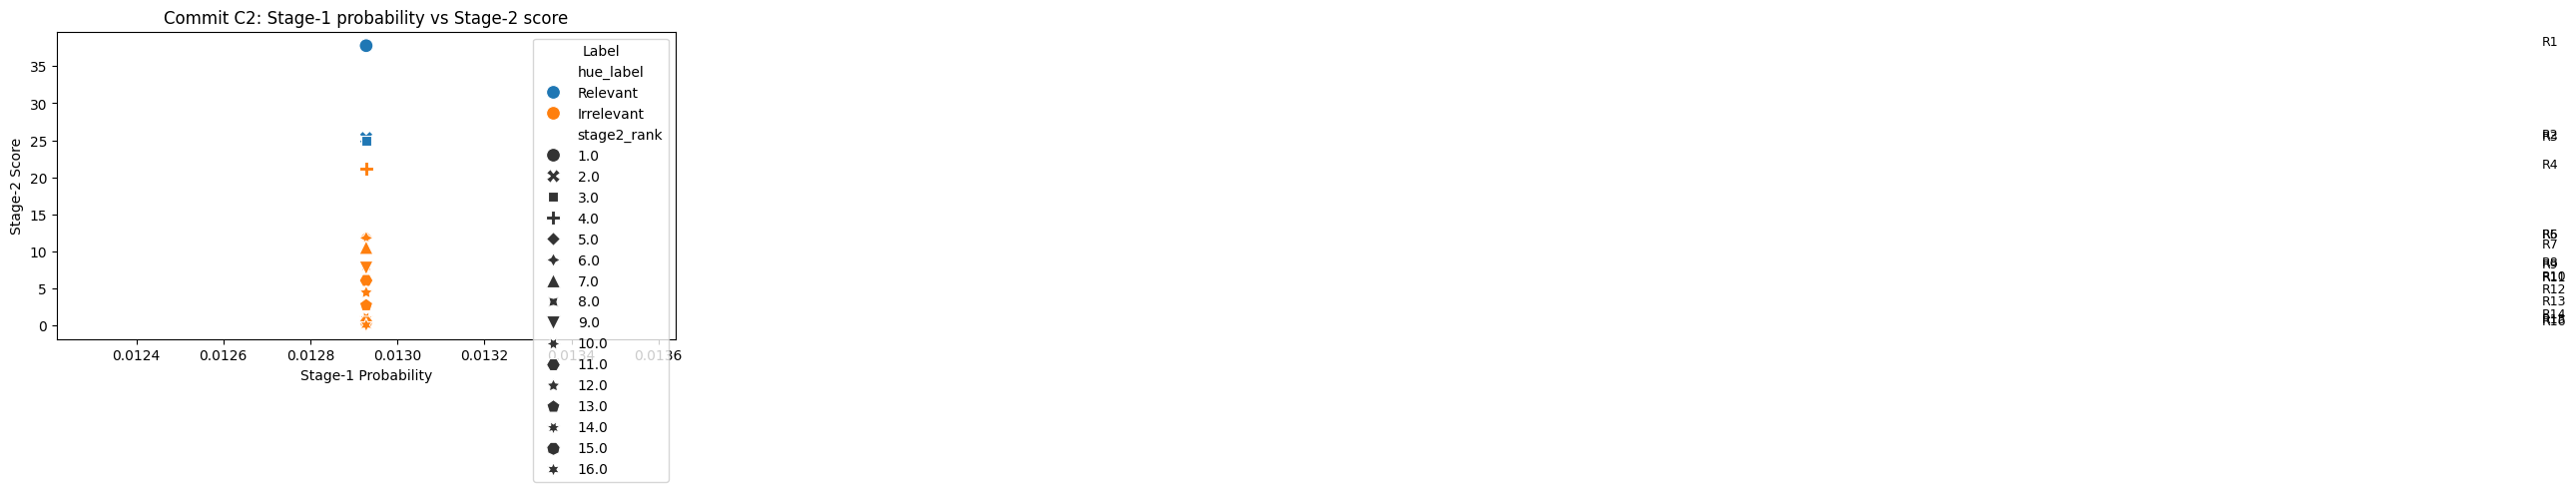

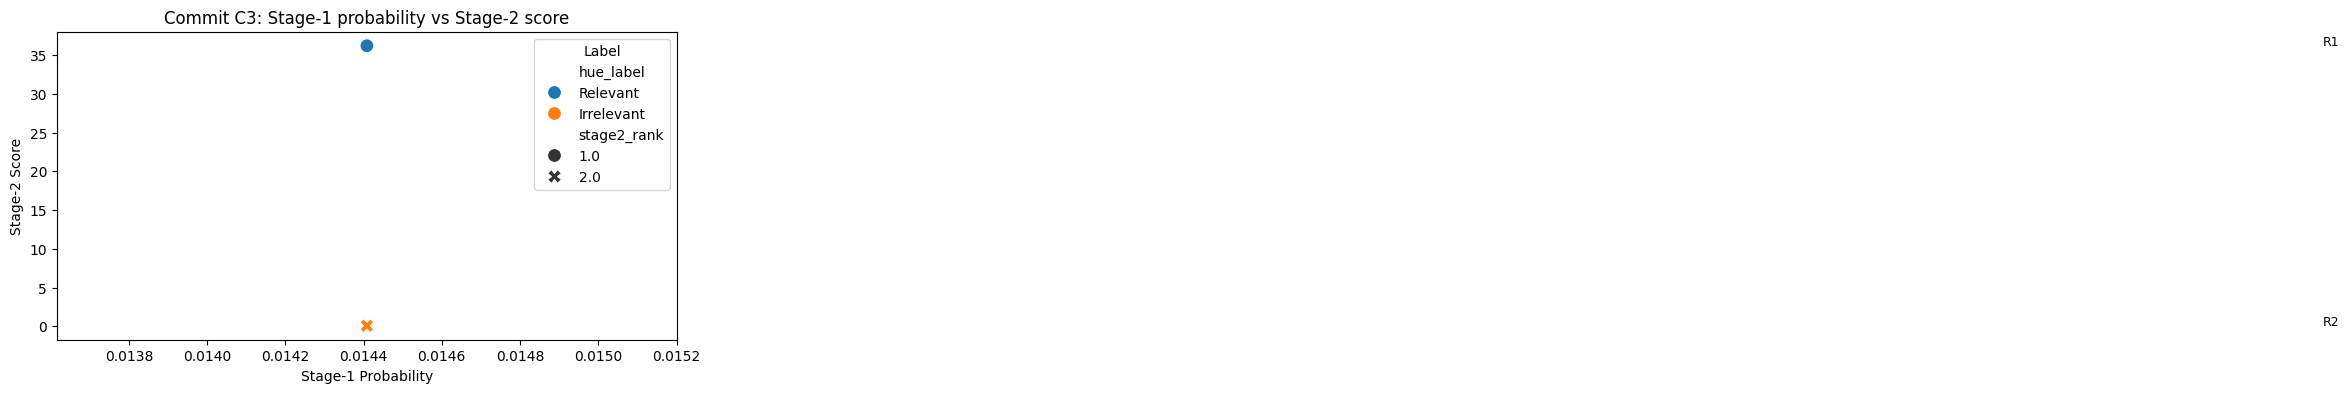

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure stage2_rank exists
df['stage2_rank'] = df.groupby('commit_id')['stage2_score'] \
                      .rank(ascending=False, method='first')

# Pick a few commits to visualize
commits_to_plot = df['commit_id'].unique()[:3]

# Identify the column to use for hue
possible_hue_cols = ['Relevant/Irrelevant', 'label', 'Label', 'relevant_irrelevant']
hue_col = None
for col in possible_hue_cols:
    if col in df.columns:
        hue_col = col
        break

if hue_col is None:
    raise ValueError(f"No suitable column found for hue. Tried: {possible_hue_cols}")

# Optionally rename to a simpler name
df.rename(columns={hue_col: 'hue_label'}, inplace=True)

for cid in commits_to_plot:
    df_c = df[df['commit_id'] == cid].copy()
    df_c = df_c.sort_values('stage2_rank')

    plt.figure(figsize=(8,4))
    sns.scatterplot(
        x='stage1_prob',
        y='stage2_score',
        hue='hue_label',       # safe column name
        style='stage2_rank',
        s=100,
        data=df_c
    )

    for i, row in df_c.iterrows():
        plt.text(row['stage1_prob'] + 0.005, row['stage2_score'], f"R{int(row['stage2_rank'])}",
                 fontsize=9, color='black')

    plt.title(f"Commit {cid}: Stage-1 probability vs Stage-2 score")
    plt.xlabel("Stage-1 Probability")
    plt.ylabel("Stage-2 Score")
    plt.legend(title="Label")
    plt.show()
